In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 예제

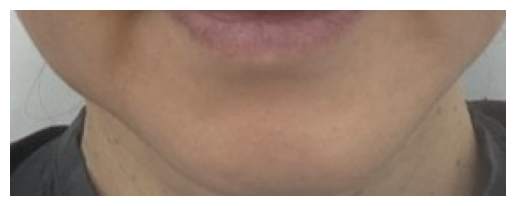

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 이미지 로드
# image = cv2.imread('/content/cat.jpg')
image = cv2.imread('/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Origin/train/chin/0006_03_F.jpg')

# 이미지를 RGB로 변환 (OpenCV는 BGR 포맷을 사용하기 때문에 변환 필요)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 이미지 출력
plt.imshow(image_rgb)
plt.axis('off')  # 축 숨기기
plt.show()

# 좌우반전 예제

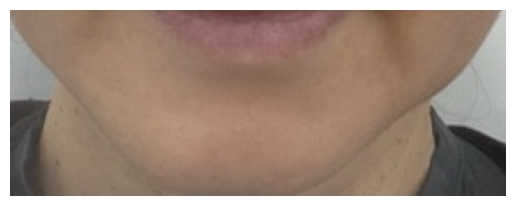

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 이미지 로드
# image = cv2.imread('/content/cat.jpg')

# 좌우 반전 (1이면 좌우 반전, 0이면 상하 반전, -1이면 둘 다 반전)
flipped_image = cv2.flip(image, 1)

# 이미지를 RGB로 변환 (OpenCV는 BGR 포맷을 사용하기 때문에 변환 필요)
flipped_image_rgb = cv2.cvtColor(flipped_image, cv2.COLOR_BGR2RGB)

# 이미지 출력
plt.imshow(flipped_image_rgb)
plt.axis('off')  # 축 숨기기
plt.show()

# # 이미지 파일로 저장
# cv2.imwrite('output_image.jpg', image)

# 밝기 예제

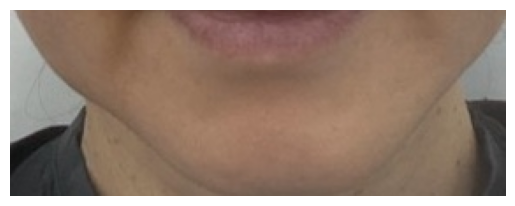

In [ ]:
# 이미지 로드
# image = cv2.imread('/content/cat.jpg')

# 밝기 조절: alpha는 곱셈, beta는 덧셈
# alpha=1.0, beta=50이면 밝기가 50만큼 증가
bright_image = cv2.convertScaleAbs(image, alpha=1.0, beta=-10)

# 이미지를 RGB로 변환 (OpenCV는 BGR 포맷을 사용하기 때문에 변환 필요)
bright_image_rgb = cv2.cvtColor(bright_image, cv2.COLOR_BGR2RGB)

# 결과 출력
plt.imshow(bright_image_rgb)
plt.axis('off')  # 축 숨기기
plt.show()

# 함수 만들기

In [ ]:
import os
import cv2

def horizon(image_path, save_dir):
    # 파일명
    image_name = image_path.split('/')[-1]
    # 이미지 로드
    image = cv2.imread(image_path)
    # 좌우 반전 (1이면 좌우 반전, 0이면 상하 반전, -1이면 둘 다 반전)
    flipped_image = cv2.flip(image, 1)
    # 이미지 파일로 저장
    cv2.imwrite(os.path.join(save_dir, image_name), flipped_image)
    print('Save horizon..', image_name)

def color_plus_10(image_path, save_dir):
    # 파일명
    image_name = image_path.split('/')[-1]
    # 이미지 로드
    image = cv2.imread(image_path)
    # 밝기 조절 +10
    bright_up_image = cv2.convertScaleAbs(image, alpha=1.0, beta=10)
    # 이미지 저장
    cv2.imwrite(os.path.join(save_dir, image_name), bright_up_image)
    print('Save color plus 10..',  image_name)

def color_minus_10(image_path, save_dir):
    # 파일명
    image_name = image_path.split('/')[-1]
    # 이미지 로드
    image = cv2.imread(image_path)
    # 밝기 조절 -10
    bright_down_image = cv2.convertScaleAbs(image, alpha=1.0, beta=-10)
    # 이미지 저장
    cv2.imwrite(os.path.join(save_dir, image_name), bright_down_image)
    print('Save color minus 10..', image_name)

def save_transformed_images(image_dir, pad_image_dir, save_dir, transformed):
    # 이미지 파일 경로 리스트 저장
    image_names = [os.path.join(image_dir, image_name) for image_name in os.listdir(image_dir) if image_name.endswith('.jpg')]
    pad_image_names = [os.path.join(pad_image_dir, image_name) for image_name in os.listdir(pad_image_dir) if image_name.endswith('.jpg')] # 스마트 패드
    all_images = image_names + pad_image_names
    # 이미지 총 개수 중 30% 추출
    size = int(len(all_images) * 0.3)
    for_transformed = random.sample(all_images, size)
    # 이미지 변경해서 저장하기
    for image_path in for_transformed:
        globals()[transformed](image_path, save_dir)

In [ ]:
import os
import random
import cv2

origin_folder = '/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Origin/'
save_base_folder = '/content/drive/MyDrive/Final_project_2조/02_2. 전처리 및 EDA_이미지/data/image/Orientation/'

for mode in os.listdir(origin_folder):
    if mode != 'val':
        continue
    mode_folder = os.path.join(origin_folder, mode)
    # print(mode_folder)
    for annotation in os.listdir(mode_folder):
        if (annotation == '.ipynb_checkpoints') | (annotation != 'chin'):
            continue
        image_dir = os.path.join(mode_folder, annotation)
        # print(image_dir)
        pad_image_dir = os.path.join(save_base_folder, mode, annotation, 'smart_pad')
        # print(pad_image_dir)
        for transformed in ['color_minus_10']: # 'horizon', 'color_plus_10',
            save_dir = os.path.join(save_base_folder, mode, annotation, transformed)
            # print(save_dir)
            save_transformed_images(image_dir, pad_image_dir, save_dir, transformed)
            print(transformed, 'DONE!')





Save color minus 10.. 1076_03_F.jpg
Save color minus 10.. 0522_02_F_chin_sp.jpg
Save color minus 10.. 0852_03_F.jpg
Save color minus 10.. 1065_03_F.jpg
Save color minus 10.. 0814_03_F.jpg
Save color minus 10.. 0402_02_F_chin_sp.jpg
Save color minus 10.. 0671_02_F_chin_sp.jpg
Save color minus 10.. 0591_03_F.jpg
Save color minus 10.. 0450_02_F_chin_sp.jpg
Save color minus 10.. 0969_03_F.jpg
Save color minus 10.. 0566_02_F_chin_sp.jpg
Save color minus 10.. 0111_03_F.jpg
Save color minus 10.. 0868_03_F.jpg
Save color minus 10.. 0922_03_F.jpg
Save color minus 10.. 0378_02_F_chin_sp.jpg
Save color minus 10.. 0922_02_F_chin_sp.jpg
Save color minus 10.. 1060_03_F.jpg
Save color minus 10.. 0673_03_F.jpg
Save color minus 10.. 0923_03_F.jpg
Save color minus 10.. 0517_02_F_chin_sp.jpg
Save color minus 10.. 1045_03_F.jpg
Save color minus 10.. 0090_02_F_chin_sp.jpg
Save color minus 10.. 0415_03_F.jpg
Save color minus 10.. 0149_02_F_chin_sp.jpg
Save color minus 10.. 1006_03_F.jpg
Save color minus 10.

1. val
    * l_perocular
        * horizon 63
        * color_plus_10 63
        * color_minus_10 63
    * r_perocular
        * horizon 64
        * color_plus_10 64
        * color_minus_10 64
    * r_cheek
        * horizon 63
        * color_plus_10 63
        * color_minus_10 63
    * l_cheek
        * horizon 63
        * color_plus_10 63
        * color_minus_10 63
    * glabellus
        * horizon 64
        * color_plus_10 64
        * color_minus_10 64
    * chin
        * horizon 64
        * color_plus_10 64
        * color_minus_10 0
    * forehead
        * horizon 64
        * color_plus_10 64
        * color_minus_10 64
2. train
    * l_perocular
        * horizon 514
        * color_plus_10 514
        * color_minus_10 514
    * r_perocular
        * horizon 507
        * color_plus_10 507
        * color_minus_10 507
    * r_cheek
        * horizon 514
        * color_plus_10 514
        * color_minus_10 514
    * l_cheek
        * horizon 510
        * color_plus_10 510
        * color_minus_10 510
    * glabellus
        * horizon 514
        * color_plus_10 514
        * color_minus_10 514
    * chin
        * horizon 508
        * color_plus_10 514
        * color_minus_10 514
    * forehead
        * horizon 508
        * color_plus_10 514
        * color_minus_10 514